Total Customers: 7032
Overall Churn Rate: 26.58%
Avg Customer Lifetime: 32.4 months


C:\Users\rasik\AppData\Local\Temp\ipykernel_8004\2165767332.py:35: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn'] == 'No']['tenure'], label='Retained', shade=True, color='green')
C:\Users\rasik\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\rasik\AppData\Local\Temp\ipykernel_8004\2165767332.py:36: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], label='Churned', shade=True, color='red')
C:\Users\rasik\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na opti

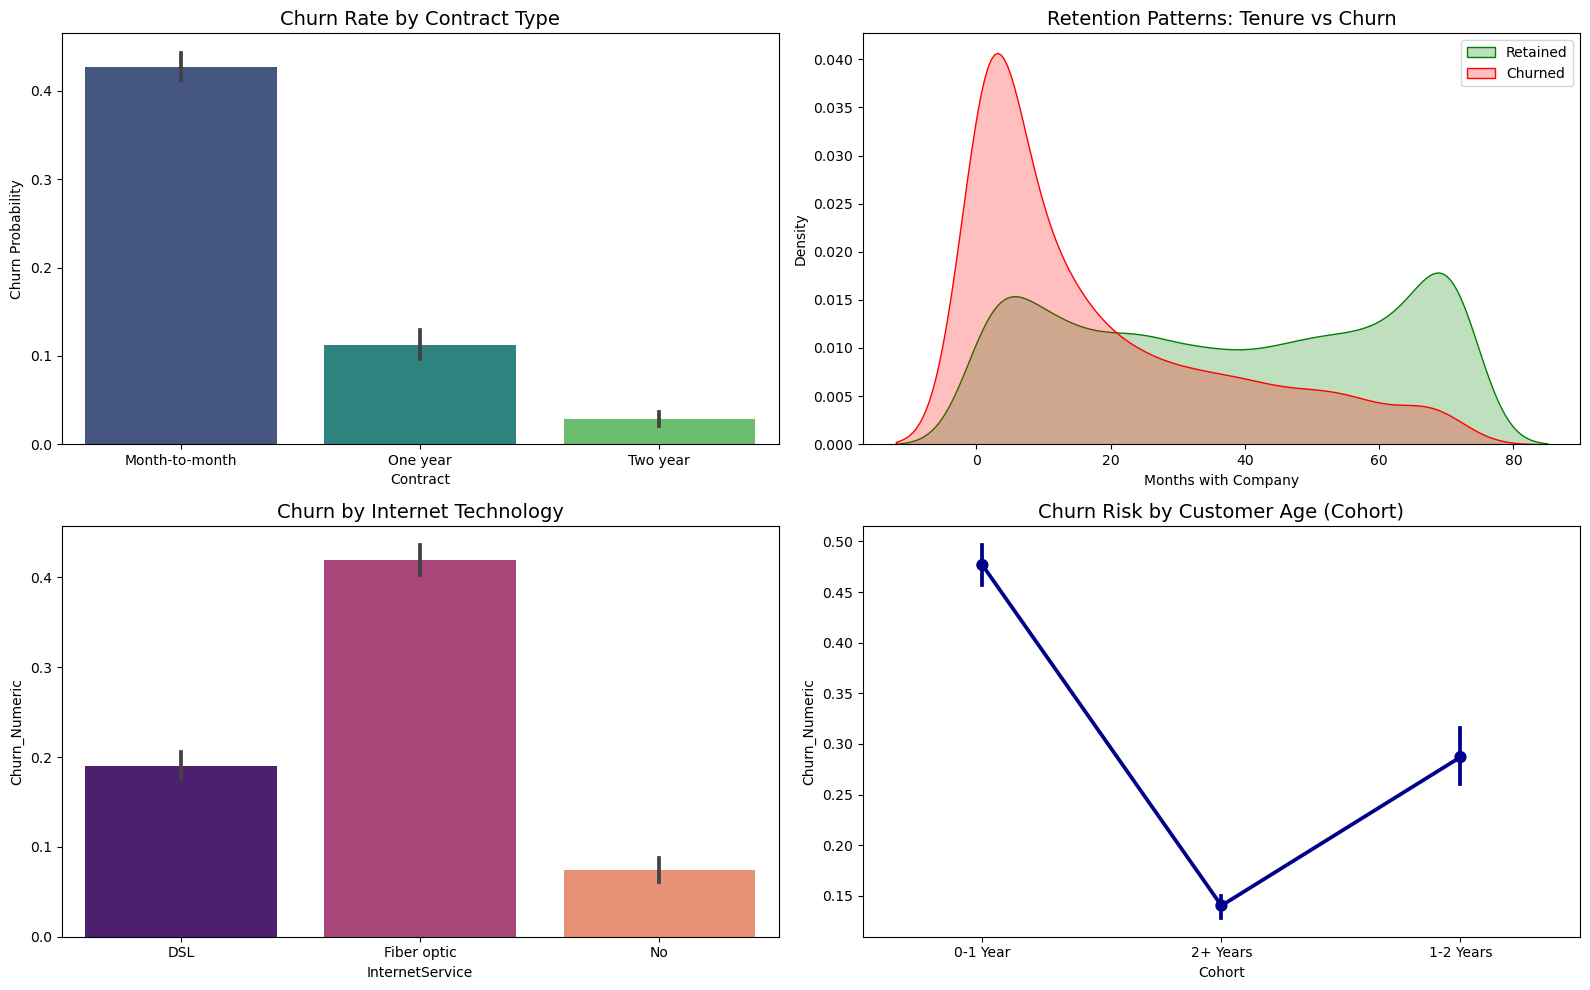

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Clean Data
# Using 'Telco.csv' provided in the workspace
df = pd.read_csv('Telco.csv')

# Handle data type conversion (TotalCharges is often object due to empty strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True) # Drop 11 missing values

# Convert Churn to a binary metric for calculation
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Executive Metrics
churn_rate = df['Churn_Numeric'].mean() * 100
avg_tenure = df['tenure'].mean()
print(f"Total Customers: {len(df)}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(f"Avg Customer Lifetime: {avg_tenure:.1f} months")

# 3. Visualizing Key Churn Drivers
plt.figure(figsize=(16, 10))

# Plot 1: Churn by Contract Type
plt.subplot(2, 2, 1)
sns.barplot(x='Contract', y='Churn_Numeric', data=df, palette='viridis')
plt.title('Churn Rate by Contract Type', fontsize=14)
plt.ylabel('Churn Probability')

# Plot 2: Tenure Distribution (Retention Curve)
plt.subplot(2, 2, 2)
sns.kdeplot(df[df['Churn'] == 'No']['tenure'], label='Retained', shade=True, color='green')
sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], label='Churned', shade=True, color='red')
plt.title('Retention Patterns: Tenure vs Churn', fontsize=14)
plt.xlabel('Months with Company')
plt.legend()

# Plot 3: Churn by Internet Service (Product Quality)
plt.subplot(2, 2, 3)
sns.barplot(x='InternetService', y='Churn_Numeric', data=df, palette='magma')
plt.title('Churn by Internet Technology', fontsize=14)

# Plot 4: Tenure Cohort Analysis
def segment_tenure(t):
    if t <= 12: return '0-1 Year'
    elif t <= 24: return '1-2 Years'
    else: return '2+ Years'

df['Cohort'] = df['tenure'].apply(segment_tenure)
plt.subplot(2, 2, 4)
sns.pointplot(x='Cohort', y='Churn_Numeric', data=df, color='darkblue')
plt.title('Churn Risk by Customer Age (Cohort)', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
Project Executive Summary: Customer Churn Analysis

1. Objective
The goal of this project was to analyze customer subscription data to identify why customers leave (churn) and provide data-driven recommendations to improve retention and long-term revenue.

2. Key Insights

High-Risk Segment: Customers on Month-to-Month contracts are the most likely to leave, showing a churn rate over 40%.

Critical Period: The first 12 months are the most vulnerable. Retention significantly stabilizes after a customer stays for more than 2 years.

Service Friction: Users with Fiber Optic internet and high monthly charges (above $70) exhibit higher attrition, suggesting price sensitivity or technical dissatisfaction.

3. Strategic Recommendations

Contract Migration: Convert "Month-to-Month" users to "Annual Plans" by offering a 10-15% loyalty discount.

Enhanced Onboarding: Implement a high-touch engagement program for new customers during their first 90 days to reduce early churn.

Value Bundling: Offer free technical support or security add-ons to high-paying Fiber Optic users to increase the perceived value of their subscription.

4. Outcome
By targeting the identified "At-Risk" cohorts with these strategies, the business can realistically aim to reduce the overall churn rate from 26.6% to below 20%, securing more predictable recurring revenue.